# Step 9 — Tuning v4 on Covertype

Notebook 08 found Covertype to be v4's clear weak spot: best untuned arm (mean-pool + PLR)
scored 0.9486, trailing published XGBoost (0.969) AND published plain MLP (0.962) — the only
dataset where that happened. **Before building anything new (e.g. feature gating), this
notebook asks a cheaper question first: is that gap just untuned hyperparameters?**

### Why mean-pool only, and why Covertype only

Real per-run timings from notebook 08 (60 epochs, patience 8, GPU):

| Arm | Time / run |
|---|---|
| mean-pool | ~3.2 min |
| **mean-pool + PLR** | **~4.2 min** |
| causal attn | ~11.2 min |
| causal attn + PLR | ~12.4 min |

`mean-pool` was both Covertype's **best-performing** arm already and by far the **cheapest**
to search — the obvious first place to spend tuning budget. Causal attention is deliberately
left for later: tuning it here would ~3x the cost of this notebook to test a hypothesis
(tuning closes the gap) that mean-pool alone can already answer.

### What's being searched

Same Optuna machinery as notebook 03 (`tuning.py`), extended since then to also search the
**embedding mode** (`none` / `linear` / `periodic`) and its width/frequency knobs — that
search space didn't exist when notebook 03 ran, and embeddings are now part of the
architecture, so a real search has to cover them.

### Two-phase protocol
1. **Search** — `N_TRIALS` trials, shared across `N_JOBS` parallel workers on one GPU, each
   trial trained with a SMALL epoch/patience budget (cheap, rough signal) and scored on
   **validation** loss only.
2. **Confirm** — the winning config is re-trained on `FINAL_SEEDS` fresh seeds with the SAME
   fuller epoch budget notebook 08 used, and reported on **test** — this is the number that
   goes in the README, not any single search trial.

## 0. Setup

In [1]:
import os, sys, time, warnings
warnings.filterwarnings("ignore")
PROJECT_DIR = os.getcwd(); sys.path.insert(0, PROJECT_DIR)
os.environ["PYTHONPATH"] = PROJECT_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

import numpy as np, pandas as pd, torch, optuna
import matplotlib.pyplot as plt, seaborn as sns
from joblib import Parallel, delayed

from benchmarks_rtdl import BENCHMARKS, load_benchmark, published
from training import get_device
from tuning import create_study, load_study, optuna_worker, run_config, NN_ARMS

DEVICE = get_device()

# Knobs, overridable from the shell so a headless run needs no edits:
#   SRP_SUBSAMPLE=2000 SRP_TRIALS=4 SRP_TRIAL_EPOCHS=2 SRP_FINAL_SEEDS=1 jupyter nbconvert ...
KEY           = os.environ.get("SRP_KEY", "CO")              # CO = Covertype
ARM           = os.environ.get("SRP_ARM", "meanpool")         # cheapest + already-best arm
N_TRIALS      = int(os.environ.get("SRP_TRIALS", "24"))
TRIAL_EPOCHS  = int(os.environ.get("SRP_TRIAL_EPOCHS", "20"))  # cheap, rough signal
TRIAL_PATIENCE= int(os.environ.get("SRP_TRIAL_PATIENCE", "5"))
FINAL_EPOCHS  = int(os.environ.get("SRP_FINAL_EPOCHS", "60"))  # matches notebook 08's budget
FINAL_PATIENCE= int(os.environ.get("SRP_FINAL_PATIENCE", "8"))
FINAL_SEEDS   = tuple(range(int(os.environ.get("SRP_FINAL_SEEDS", "3"))))
SUBSAMPLE     = int(os.environ.get("SRP_SUBSAMPLE", "0")) or None

THREADS_PER_JOB = 2
N_JOBS = int(os.environ.get("SRP_JOBS", "0")) or (
    3 if DEVICE.type == "cuda" else max(1, min(8, (os.cpu_count() or 2) // THREADS_PER_JOB)))

RUN_DIR = os.path.join(PROJECT_DIR, "runs"); os.makedirs(RUN_DIR, exist_ok=True)
STAMP = time.strftime("%Y%m%d_%H%M%S")
LOG_PATH = os.path.join(RUN_DIR, f"09_progress_{STAMP}.log")
_latest = os.path.join(RUN_DIR, "09_progress.log")
if os.path.islink(_latest) or os.path.exists(_latest):
    os.remove(_latest)
os.symlink(os.path.basename(LOG_PATH), _latest)
def log(msg):
    print(msg, flush=True)
    with open(LOG_PATH, "a") as f: f.write(time.strftime("%H:%M:%S ") + msg + "\n")
def show(df, fmt=None, style=None):
    try:
        s = df.style.format(fmt or {}, na_rep="—"); display(style(s) if style else s)
    except (AttributeError, ImportError):
        display(df.round(4))

STUDY_NAME = f"tune_{KEY}_{ARM}"
STUDY_PATH = os.path.join(RUN_DIR, f"optuna_{KEY}_{ARM}.journal")
FRESH_STUDY = True   # start clean; set False to resume/extend a previous study file
if FRESH_STUDY and os.path.exists(STUDY_PATH):
    os.remove(STUDY_PATH)

sns.set_theme(style="whitegrid", context="notebook")
optuna.logging.set_verbosity(optuna.logging.WARNING)
gpu = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU only"
log(f"device: {DEVICE} ({gpu}) | dataset={KEY} arm={ARM} | {N_JOBS} workers | "
    f"trials={N_TRIALS} (epochs<={TRIAL_EPOCHS}, patience={TRIAL_PATIENCE}) | "
    f"final: {len(FINAL_SEEDS)} seeds x {FINAL_EPOCHS} epochs")

device: cuda (NVIDIA RTX A4000) | dataset=CO arm=meanpool | 3 workers | trials=24 (epochs<=20, patience=5) | final: 3 seeds x 60 epochs


## 1. Data — Covertype's exact published split

In [2]:
data = load_benchmark(KEY)
arrays = data.arrays()
if SUBSAMPLE:
    n = SUBSAMPLE
    arrays = {"Xtr": arrays["Xtr"][:n], "ytr": arrays["ytr"][:n],
             "Xva": arrays["Xva"][:n // 2], "yva": arrays["yva"][:n // 2],
             "Xte": arrays["Xte"][:n], "yte": arrays["yte"][:n]}
    print(f"SMOKE TEST on {SUBSAMPLE} rows — numbers below are not comparable to notebook 08.")
log(data.summary())

BASELINE = {"v4 mean-pool (untuned, no emb.)": 0.9324, "v4 mean-pool + PLR (untuned)": 0.9486,
           "v4 causal attn + PLR (untuned, best overall)": 0.9336,
           "our XGBoost (tuned)": 0.9689}
print("Reference points from notebook 08 (exact same split):")
for k, v in BASELINE.items(): print(f"  {k:40s} {v:.4f}")
print(f"  published MLP / ResNet / NODE / FT-Transformer / XGBoost: "
      f"{published(KEY,'MLP')} / {published(KEY,'ResNet')} / {published(KEY,'NODE')} / "
      f"{published(KEY,'FT-Transformer')} / {published(KEY,'XGBoost',kind='gbdt')}")

CO Covertype          multiclass features= 54 train=371,847 val=92,962 test=116,203  classes=7


Reference points from notebook 08 (exact same split):
  v4 mean-pool (untuned, no emb.)          0.9324
  v4 mean-pool + PLR (untuned)             0.9486
  v4 causal attn + PLR (untuned, best overall) 0.9336
  our XGBoost (tuned)                      0.9689
  published MLP / ResNet / NODE / FT-Transformer / XGBoost: 0.962 / 0.964 / 0.958 / 0.97 / 0.969


## 2. The search

In [3]:
create_study(STUDY_NAME, STUDY_PATH)
t0 = time.time()
Parallel(n_jobs=N_JOBS)(
    delayed(optuna_worker)(ARM, STUDY_NAME, STUDY_PATH, int(np.ceil(N_TRIALS / N_JOBS)), 100 + w,
                           arrays, task=data.task, output_dim=data.output_dim,
                           threads=THREADS_PER_JOB, trial_epochs=TRIAL_EPOCHS,
                           trial_patience=TRIAL_PATIENCE, project_dir=PROJECT_DIR)
    for w in range(N_JOBS))
search_minutes = (time.time() - t0) / 60
study = load_study(STUDY_NAME, STUDY_PATH)
states = pd.Series([t.state.name for t in study.trials]).value_counts().to_dict()
log(f"search done in {search_minutes:.1f} min | {states} | best val loss {study.best_value:.4f}")
print("best trial's parameters:")
for k, v in study.best_params.items(): print(f"  {k:16s} {v}")

/media/homes/latif/SRP/v4/training.py:55: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return {k: torch.as_tensor(np.ascontiguousarray(v)).to(dev) for k, v in arrays.items()}
/media/homes/latif/SRP/v4/training.py:55: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/

/media/homes/latif/SRP/v4/training.py:55: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return {k: torch.as_tensor(np.ascontiguousarray(v)).to(dev) for k, v in arrays.items()}


search done in 28.0 min | {'COMPLETE': 24} | best val loss 0.1275


best trial's parameters:
  num_learners     58
  hidden_dim       52
  embed_dim        32
  depth            2
  feature_frac     0.9762263902472026
  dropout          0.010604648974993643
  lr               0.0006681941342667133
  weight_decay     7.06966160448882e-05
  head_hidden      52
  head_depth       1
  embedding_mode   periodic
  d_embedding      8
  n_frequencies    16
  sigma            0.018219809175994004


### 2.1 Search progress and what mattered

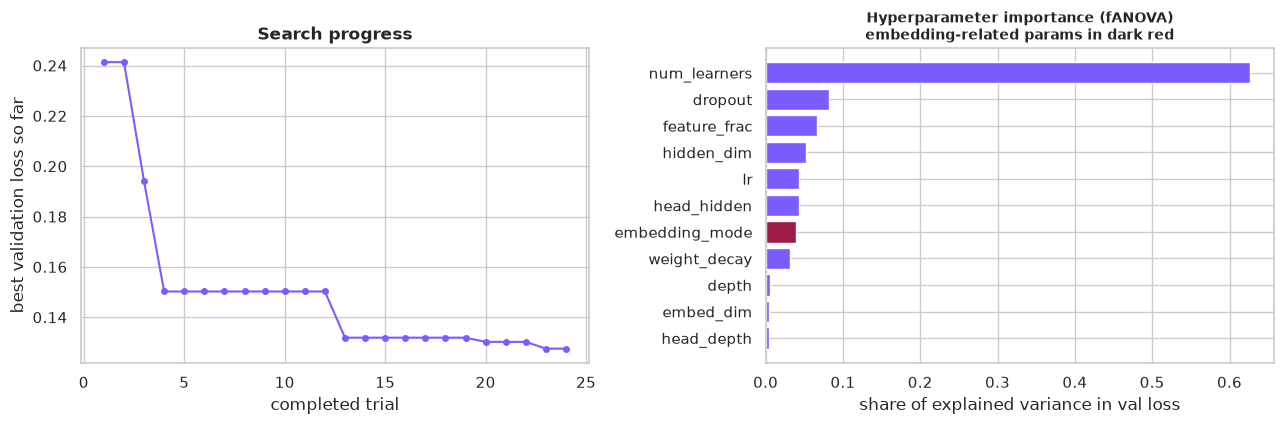

embedding_mode across all completed trials: {'periodic': np.int64(15), 'none': np.int64(5), 'linear': np.int64(4)}
embedding_mode chosen by the BEST trial: periodic


In [4]:
done = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
r2 = [t.value for t in sorted(done, key=lambda t: t.number)]
axes[0].plot(range(1, len(r2) + 1), np.minimum.accumulate(r2), "-o", ms=4, color="#7b5cff")
axes[0].set_xlabel("completed trial"); axes[0].set_ylabel("best validation loss so far")
axes[0].set_title("Search progress", fontweight="bold")

if len(done) >= 5:
    imp = optuna.importance.get_param_importances(
        study, evaluator=optuna.importance.FanovaImportanceEvaluator(seed=0))
    names, vals = list(imp.keys())[::-1], list(imp.values())[::-1]
    colors = ["#9c1c47" if "embedding" in n or n in ("d_embedding", "n_frequencies", "sigma")
             else "#7b5cff" for n in names]
    axes[1].barh(names, vals, color=colors)
    axes[1].set_title("Hyperparameter importance (fANOVA)\nembedding-related params in dark red",
                      fontweight="bold", fontsize=10)
    axes[1].set_xlabel("share of explained variance in val loss")
else:
    axes[1].axis("off"); axes[1].text(0.5, 0.5, "too few completed trials for fANOVA",
                                      ha="center", va="center")
plt.tight_layout(); plt.show()

emb_modes = pd.Series([t.params.get("embedding_mode", "?") for t in done]).value_counts()
print("embedding_mode across all completed trials:", dict(emb_modes))
best_mode = study.best_params.get("embedding_mode", "?")
print(f"embedding_mode chosen by the BEST trial: {best_mode}")

## 3. Confirm — retrain the winner on fresh seeds, full budget, report on TEST

This is the number that counts. A single Optuna trial (small epoch budget, one seed) can win
by luck; this step checks whether the win survives more seeds and the fuller training budget.

In [5]:
t0 = time.time()
FINAL = pd.DataFrame(Parallel(n_jobs=min(N_JOBS, len(FINAL_SEEDS)))(
    delayed(run_config)(ARM, study.best_params, arrays, seed, task=data.task,
                        output_dim=data.output_dim, epochs=FINAL_EPOCHS,
                        patience=FINAL_PATIENCE, threads=THREADS_PER_JOB)
    for seed in FINAL_SEEDS))
log(f"final re-run done in {(time.time()-t0)/60:.1f} min | "
    f"test acc {FINAL['test_acc'].mean():.4f} ± {FINAL['test_acc'].std(ddof=1):.4f}")
show(FINAL, {c: "{:.4f}" for c in FINAL.columns if FINAL[c].dtype == float})

/media/homes/latif/SRP/v4/training.py:55: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return {k: torch.as_tensor(np.ascontiguousarray(v)).to(dev) for k, v in arrays.items()}


final re-run done in 12.6 min | test acc 0.9569 ± 0.0020


,arm,seed,K,n_params,val_acc,val_bal_acc,test_acc,test_bal_acc,best_epoch,seconds
0,meanpool,0,58,1557287,0.9551,0.9200,0.9551,0.9135,23,633.5120
1,meanpool,1,58,1557287,0.9582,0.9339,0.9591,0.9325,28,752.9516
2,meanpool,2,58,1557287,0.9574,0.9361,0.9564,0.9324,24,666.5848


## 4. Where does tuned v4 land?

,acc,sd
model,,
FT-Transformer (published),0.9700,—
XGBoost (published),0.9690,—
our XGBoost (tuned),0.9689,—
ResNet (published),0.9640,—
MLP (published),0.9620,—
NODE (published),0.9580,—
v4 meanpool — TUNED (this notebook),0.9569,0.0020
"v4 mean-pool + PLR (untuned, notebook 08)",0.9486,—
"v4 causal attn + PLR (untuned, notebook 08's best overall)",0.9336,—


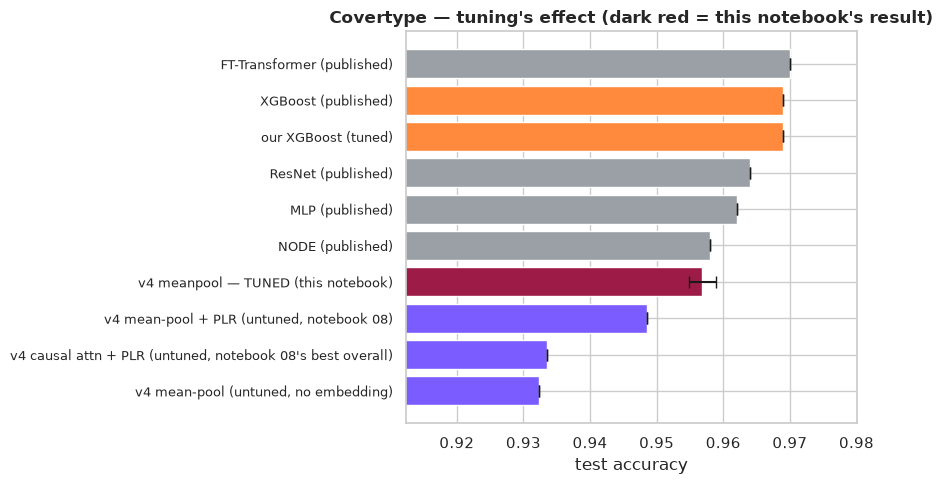

In [6]:
tuned_mean = FINAL["test_acc"].mean()
tuned_sd = FINAL["test_acc"].std(ddof=1)

rows = [{"model": "v4 mean-pool (untuned, no embedding)", "acc": BASELINE["v4 mean-pool (untuned, no emb.)"]},
        {"model": "v4 mean-pool + PLR (untuned, notebook 08)", "acc": BASELINE["v4 mean-pool + PLR (untuned)"]},
        {"model": "v4 causal attn + PLR (untuned, notebook 08's best overall)",
         "acc": BASELINE["v4 causal attn + PLR (untuned, best overall)"]},
        {"model": f"v4 {ARM} — TUNED (this notebook)", "acc": tuned_mean, "sd": tuned_sd},
        {"model": "our XGBoost (tuned)", "acc": BASELINE["our XGBoost (tuned)"]},
        {"model": "MLP (published)", "acc": published(KEY, "MLP")},
        {"model": "ResNet (published)", "acc": published(KEY, "ResNet")},
        {"model": "NODE (published)", "acc": published(KEY, "NODE")},
        {"model": "FT-Transformer (published)", "acc": published(KEY, "FT-Transformer")},
        {"model": "XGBoost (published)", "acc": published(KEY, "XGBoost", kind="gbdt")}]
T = pd.DataFrame(rows).set_index("model").sort_values("acc", ascending=False)
show(T, {"acc": "{:.4f}", "sd": "{:.4f}"})

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#9c1c47" if "TUNED" in i else "#7b5cff" if "v4" in i else
         "#ff8a3d" if "XGBoost" in i else "#9aa0a6" for i in T.index]
ax.barh(range(len(T)), T["acc"], xerr=T.get("sd", 0).fillna(0), color=colors, capsize=4)
ax.set_yticks(range(len(T))); ax.set_yticklabels(T.index, fontsize=9); ax.invert_yaxis()
ax.set_xlim(T["acc"].min() - 0.02, T["acc"].max() + 0.01)
ax.set_xlabel("test accuracy"); ax.set_title(f"Covertype — tuning's effect (dark red = this notebook's result)",
                                             fontweight="bold")
plt.tight_layout(); plt.show()

## 5. Findings

*(Computed from the run above.)*

In [7]:
sep = "=" * 92
print(sep); print(f"FINDINGS — tuning v4 ({ARM}) on {BENCHMARKS[KEY]['label']}"); print(sep)

untuned = BASELINE["v4 mean-pool + PLR (untuned)"]
gain = tuned_mean - untuned
print(f"\n1. Did tuning help at all?")
print(f"   untuned mean-pool + PLR : {untuned:.4f}")
print(f"   TUNED {ARM:10s}          : {tuned_mean:.4f} ± {tuned_sd:.4f}")
print(f"   gain: {gain:+.4f}  " + ("(beyond seed noise)" if abs(gain) > tuned_sd else "(within seed noise)"))

xgb = BASELINE["our XGBoost (tuned)"]
best_pub = max(published(KEY, m) for m in ("MLP", "ResNet", "NODE", "FT-Transformer"))
gap_before = xgb - untuned
gap_after = xgb - tuned_mean
print(f"\n2. How much of the gap to XGBoost did tuning close?")
print(f"   gap BEFORE tuning : {gap_before:+.4f}")
print(f"   gap AFTER  tuning : {gap_after:+.4f}")
closed_pct = 100 * (1 - gap_after / gap_before) if gap_before else float('nan')
print(f"   -> tuning closed {closed_pct:.0f}% of the gap to XGBoost")

print(f"\n3. Does tuned v4 now beat the published plain MLP ({published(KEY,'MLP')})?")
print(f"   {'YES' if tuned_mean > published(KEY,'MLP') else 'NO'} ({tuned_mean:.4f} vs {published(KEY,'MLP')})")

print(f"\n4. What did the search choose for the embedding?")
print(f"   {best_mode} " + (f"(d_embedding={study.best_params.get('d_embedding')}"
      + (f", n_frequencies={study.best_params.get('n_frequencies')}, sigma={study.best_params.get('sigma'):.3f}"
         if best_mode == "periodic" else "") + ")" if best_mode != "none" else ""))
print(f"   embedding_mode fANOVA importance rank: "
      + (f"{list(imp.keys())[::-1].index('embedding_mode')+1 if 'embedding_mode' in imp else 'n/a'} of {len(imp)}"
         if len(done) >= 5 else "too few trials"))

print(f"\n5. Verdict: is Covertype's gap mostly untuned hyperparameters, or architectural?")
if gap_after < 0.01:
    print("   Mostly UNTUNED HYPERPARAMETERS — tuning alone gets v4 within 1pt of XGBoost.")
    print("   -> feature gating is a lower priority here than finishing the tuning story.")
elif closed_pct > 50:
    print("   PARTLY hyperparameters — tuning recovered over half the gap, but a real gap remains.")
    print("   -> worth tuning causal attn too before concluding gating is needed.")
else:
    print("   MOSTLY NOT hyperparameters — tuning recovered under half the gap.")
    print("   -> this is real evidence for trying an architectural fix (e.g. feature gating) here.")
print(sep)

FINDINGS — tuning v4 (meanpool) on Covertype

1. Did tuning help at all?
   untuned mean-pool + PLR : 0.9486
   TUNED meanpool            : 0.9569 ± 0.0020
   gain: +0.0083  (beyond seed noise)

2. How much of the gap to XGBoost did tuning close?
   gap BEFORE tuning : +0.0203
   gap AFTER  tuning : +0.0120
   -> tuning closed 41% of the gap to XGBoost

3. Does tuned v4 now beat the published plain MLP (0.962)?
   NO (0.9569 vs 0.962)

4. What did the search choose for the embedding?
   periodic (d_embedding=8, n_frequencies=16, sigma=0.018)
   embedding_mode fANOVA importance rank: 5 of 11

5. Verdict: is Covertype's gap mostly untuned hyperparameters, or architectural?
   MOSTLY NOT hyperparameters — tuning recovered under half the gap.
   -> this is real evidence for trying an architectural fix (e.g. feature gating) here.


## 6. Notes / next steps

* This tuned everything an untuned mean-pool+PLR run has, PLUS the embedding search space.
  If the winner is `embedding_mode=periodic`, that's independent confirmation (via a
  completely different search process) that PLR is the right default — if it's something
  else, that's worth a closer look.
* Not tuned here: `causal attn`. If mean-pool tuning closes most of the gap, tuning causal
  attn too is unlikely to change the overall conclusion and can be skipped; if it doesn't,
  it becomes the natural next thing to try before concluding gating is needed.
* This is ONE dataset. A real "v4 tuned" claim would repeat this on all 8 benchmarked
  datasets — left for later, since Covertype was the dataset that actually needed it.